# Cell Segmentation — Model Evaluation & Benchmark

Compares **UNetResNet18 · DINOv2Seg · SegFormerSeg · UNet3D** on the same held-out
validation volumes (seed=42 split, identical to training).

| Criterion | Coverage |
|---|---|
| Segmentation quality | mIoU, mDice, Precision, Recall, Specificity, Kappa |
| Boundary quality | Boundary-F1 per class |
| Speed | ms/image, FPS |
| Model footprint | #params, checkpoint MB, peak inference RAM |
| Visual | side-by-side, error maps, confusion matrices |
| Consistency | per-volume mIoU box-plots |
| Rare-class focus | class 2 (only ~1 % of pixels) deep-dive |
| Depth bias | performance vs slice position in volume |

In [1]:
# ── 0. Cleanup (close other notebooks first in VS Code) ─────────────────────
import gc
gc.collect()
print('Ready.')

Ready.


In [2]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import os, sys, time, tracemalloc
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from tqdm import tqdm
from scipy.ndimage import binary_erosion, binary_dilation

OWLO_DIR  = r'C:\Users\marti\Desktop\Owlo-test'
UTILS_DIR = os.path.join(OWLO_DIR, 'utils')
if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

from models import UNetResNet18, DINOv2Seg, SegFormerSeg, UNet3D, SegFormerSeg3D
from train_functions import (
    load_tif_stack, process_mask,
    predict_slice, predict_slice_3d,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CMAP   = mcolors.ListedColormap(['black', 'deepskyblue', 'tomato'])
print('Device:', DEVICE)

Device: cpu


In [3]:
# ── 2. Configuration ─────────────────────────────────────────────────────────
DATA_DIR  = r'C:\Users\marti\Downloads\2025-11-19_Simu_twocells\2025-11-19_Simu_twocells'
CKPT_DIR  = os.path.join(OWLO_DIR, 'model_weights')

# Reproduce exact train/val split (seed=42, val_frac=0.15)
ALL_K = list(range(100))
rng   = np.random.default_rng(seed=42)
perm  = rng.permutation(ALL_K).tolist()
n_val = max(1, int(len(perm) * 0.15))
VAL_K = sorted(perm[:n_val])
print(f'Val volumes ({len(VAL_K)}): {VAL_K}')

# Model checkpoint filenames
CKPTS = {
    'UNetResNet18'  : 'best_unet_resnet18.pth',
    'DINOv2Seg'     : 'best_dinov2_seg.pth',
    'SegFormerSeg'  : 'best_segformer.pth',
    'UNet3D'        : 'best_unet3d.pth',
}

# Load checkpoints exist?
for mname, ckpt in CKPTS.items():
    path = os.path.join(CKPT_DIR, ckpt)
    exists = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  {mname:16s}  {exists}')

# Try to load SegFormerSeg3D if it exists
CKPTS_OPT = {}
ckpt_sf3d = os.path.join(CKPT_DIR, 'best_segformer3d.pth')
if os.path.exists(ckpt_sf3d):
    CKPTS_OPT['SegFormerSeg3D'] = 'best_segformer3d.pth'
    print(f'  SegFormerSeg3D        OK  (optional)')

NUM_CLASSES = 3
IMG_SIZES = {
    'UNetResNet18' : (128, 128),
    'DINOv2Seg'    : (224, 224),
    'SegFormerSeg' : (256, 256),
}

Val volumes (15): [2, 18, 21, 24, 25, 27, 33, 42, 50, 52, 56, 59, 71, 81, 92]
  UNetResNet18      OK
  DINOv2Seg         OK
  SegFormerSeg      OK
  UNet3D            OK
  SegFormerSeg3D        OK  (optional)


In [ ]:
# ── 2b. Model specs ───────────────────────────────────────────────────────────
# Central registry: every downstream cell reads from MODEL_SPECS.
# Add or remove entries here to change which models are evaluated.

DEPTH_3D     = 5    # number of slices fed to 3-D models
SLICE_STRIDE = 2    # evaluate every Nth slice (set to 1 for all slices)

MODEL_SPECS = {
    'UNetResNet18': dict(
        cls      = UNetResNet18,
        kwargs   = dict(num_classes=NUM_CLASSES, in_channels=1, pretrained=False),
        ckpt     = os.path.join(CKPT_DIR, CKPTS['UNetResNet18']),
        img_size = (128, 128),
        mode     = '2d',
        color    = '#FF9800',
    ),
    'DINOv2Seg': dict(
        cls      = DINOv2Seg,
        kwargs   = dict(num_classes=NUM_CLASSES),
        ckpt     = os.path.join(CKPT_DIR, CKPTS['DINOv2Seg']),
        img_size = (224, 224),
        mode     = '2d',
        color    = '#2196F3',
    ),
    'SegFormerSeg': dict(
        cls      = SegFormerSeg,
        kwargs   = dict(num_classes=NUM_CLASSES, freeze_encoder=True),
        ckpt     = os.path.join(CKPT_DIR, CKPTS['SegFormerSeg']),
        img_size = (256, 256),
        mode     = '2d',
        color    = '#4CAF50',
    ),
    'UNet3D': dict(
        cls      = UNet3D,
        kwargs   = dict(num_classes=NUM_CLASSES),
        ckpt     = os.path.join(CKPT_DIR, CKPTS['UNet3D']),
        img_size = (128, 128),
        mode     = '3d',
        depth    = DEPTH_3D,
        color    = '#9C27B0',
    ),
}

# Optionally include SegFormerSeg3D if its checkpoint was found above
if CKPTS_OPT:
    MODEL_SPECS['SegFormerSeg3D'] = dict(
        cls      = SegFormerSeg3D,
        kwargs   = dict(num_classes=NUM_CLASSES),
        ckpt     = os.path.join(CKPT_DIR, CKPTS_OPT['SegFormerSeg3D']),
        img_size = (256, 256),
        mode     = '3d',
        depth    = DEPTH_3D,
        color    = '#E91E63',
    )

print(f'MODEL_SPECS: {list(MODEL_SPECS)}')
print(f'DEPTH_3D={DEPTH_3D}  SLICE_STRIDE={SLICE_STRIDE}')


In [4]:
# ── 3. Helper functions ───────────────────────────────────────────────────────

def confusion_matrix(preds_list, gts_list, num_classes=3):
    """Fast confusion matrix using np.bincount (avoids nested class loops)."""
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for p, g in zip(preds_list, gts_list):
        cm += np.bincount(
            num_classes * g.flatten().astype(np.int64) + p.flatten().astype(np.int64),
            minlength=num_classes ** 2,
        ).reshape(num_classes, num_classes)
    return cm

def metrics_from_cm(cm):
    """Derive all per-class and global metrics from a confusion matrix."""
    nc = cm.shape[0]
    tp = np.diag(cm).astype(float)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    tn = cm.sum() - tp - fp - fn
    eps = 1e-8
    precision   = tp / (tp + fp + eps)
    recall      = tp / (tp + fn + eps)
    specificity = tn / (tn + fp + eps)
    iou         = tp / (tp + fp + fn + eps)
    dice        = 2*tp / (2*tp + fp + fn + eps)
    pixel_acc   = tp.sum() / cm.sum()
    exp_acc     = (cm.sum(0) * cm.sum(1)).sum() / cm.sum()**2
    kappa       = (pixel_acc - exp_acc) / (1 - exp_acc + eps)
    return dict(
        iou=iou, dice=dice, precision=precision,
        recall=recall, specificity=specificity,
        pixel_acc=float(pixel_acc), kappa=float(kappa),
        mean_iou=float(iou[1:].mean()),
        mean_dice=float(dice[1:].mean()),
    )

def boundary_f1(pred_cls, gt_cls, tolerance=2):
    """Boundary F1: fraction of boundary pixels within `tolerance` px of GT boundary."""
    if pred_cls.sum() + gt_cls.sum() == 0:
        return 1.0
    if pred_cls.sum() == 0 or gt_cls.sum() == 0:
        return 0.0
    struct = np.ones((3, 3), dtype=bool)
    tol    = np.ones((2*tolerance+1, 2*tolerance+1), dtype=bool)
    pred_b = pred_cls & ~binary_erosion(pred_cls, structure=struct)
    gt_b   = gt_cls   & ~binary_erosion(gt_cls,   structure=struct)
    pred_bd = binary_dilation(pred_b, structure=tol)
    gt_bd   = binary_dilation(gt_b,   structure=tol)
    prec = (pred_b & gt_bd).sum() / (pred_b.sum() + 1e-8)
    rec  = (gt_b & pred_bd).sum() / (gt_b.sum()  + 1e-8)
    return float(2*prec*rec / (prec+rec+1e-8))

def compute_boundary_f1s(preds_list, gts_list, num_classes=3, tolerance=2):
    bf1 = np.zeros(num_classes)
    for p, g in zip(preds_list, gts_list):
        for c in range(1, num_classes):
            bf1[c] += boundary_f1(p == c, g == c, tolerance)
    return bf1 / max(len(preds_list), 1)

def benchmark_inference(model, dummy_input, n_warmup=5, n_runs=25):
    model.eval()
    with torch.no_grad():
        for _ in range(n_warmup):
            model(dummy_input.to(DEVICE))
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(dummy_input.to(DEVICE))
            times.append((time.perf_counter() - t0) * 1000)
    return dict(mean=np.mean(times), std=np.std(times),
                p50=np.percentile(times, 50), p95=np.percentile(times, 95),
                fps=1000/np.mean(times))

def peak_ram_mb(model, dummy_input):
    model.eval()
    tracemalloc.start()
    with torch.no_grad():
        model(dummy_input.to(DEVICE))
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024**2

print('Helper functions defined.')

Helper functions defined.


In [5]:
# ── 4. Load models ────────────────────────────────────────────────────────────
MODELS = {}   # name → nn.Module  (only loaded if checkpoint exists)

for name, spec in MODEL_SPECS.items():
    if not os.path.exists(spec['ckpt']):
        print(f'  [SKIP] {name}: checkpoint not found at {spec["ckpt"]}')
        continue
    m = spec['cls'](**spec['kwargs'])
    m.load_state_dict(torch.load(spec['ckpt'], map_location=DEVICE))
    m.to(DEVICE).eval()
    MODELS[name] = m
    n_params = sum(p.numel() for p in m.parameters())
    n_train  = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  [OK]   {name}: {n_train:,} trainable / {n_params:,} total params')

print(f'\nLoaded {len(MODELS)} model(s):', list(MODELS))

  [OK]   UNetResNet18: 14,407,331 trainable / 14,407,331 total params
  [OK]   DINOv2Seg: 652,739 trainable / 22,709,315 total params
  [OK]   SegFormerSeg: 2,815,459 trainable / 15,966,883 total params
  [OK]   UNet3D: 1,074,987 trainable / 1,074,987 total params
  [OK]   SegFormerSeg3D: 2,815,479 trainable / 15,966,903 total params

Loaded 5 model(s): ['UNetResNet18', 'DINOv2Seg', 'SegFormerSeg', 'UNet3D', 'SegFormerSeg3D']


In [6]:
# ── 5. Full evaluation on the validation set ──────────────────────────────────
# Each model is evaluated at its own training resolution (img_size from MODEL_SPECS).
# Both prediction AND ground-truth are at that resolution so metrics match the
# numbers seen during training, and pred/gt shapes are always identical.

RESULTS = {}   # name → {'preds', 'gts', 'per_vol_miou', 'per_slice_depths'}

def resize_gt(gt_np, size):
    """Resize an integer GT mask (H,W) to `size` using nearest-neighbour."""
    gt_t = torch.from_numpy(gt_np).unsqueeze(0).unsqueeze(0).float()
    gt_r = F.interpolate(gt_t, size=size, mode='nearest').squeeze().long().numpy()
    return gt_r

for name, model in MODELS.items():
    spec    = MODEL_SPECS[name]
    mode    = spec['mode']
    sz      = spec['img_size']    # e.g. (128,128) for UNet, (256,256) for SegFormer
    depth   = spec.get('depth', DEPTH_3D)

    all_preds, all_gts = [], []
    per_vol_miou       = []
    per_slice_depths   = []

    print(f'\nEvaluating {name} at {sz} …')
    with torch.no_grad():
        for k in tqdm(VAL_K, desc=name):
            img_vol = load_tif_stack(
                os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).astype(np.float32) / 255.0
            msk_vol = load_tif_stack(os.path.join(DATA_DIR, f'mask_{k}.tif'))
            n_slices = img_vol.shape[0]
            half     = depth // 2

            vol_preds, vol_gts = [], []
            for centre in range(0, n_slices, SLICE_STRIDE):
                # GT at model's training resolution → consistent with pred size
                gt_native = process_mask(msk_vol[centre])
                gt = resize_gt(gt_native, sz) if sz is not None else gt_native

                if mode == '2d':
                    pred = predict_slice(model, img_vol[centre], DEVICE, img_size=sz)
                else:
                    ids   = [max(0, min(n_slices-1, centre+d-half)) for d in range(depth)]
                    patch = np.stack([img_vol[s] for s in ids], axis=0)
                    pred  = predict_slice_3d(model, patch, DEVICE, img_size=sz)

                vol_preds.append(pred)
                vol_gts.append(gt)
                depth_frac = centre / max(n_slices - 1, 1)
                slice_iou = []
                for c in range(1, NUM_CLASSES):
                    inter = ((pred == c) & (gt == c)).sum()
                    union = ((pred == c) | (gt == c)).sum()
                    slice_iou.append(inter / (union + 1e-8))
                per_slice_depths.append((depth_frac, float(np.mean(slice_iou))))

            cm_vol = confusion_matrix(vol_preds, vol_gts, NUM_CLASSES)
            m_vol  = metrics_from_cm(cm_vol)
            per_vol_miou.append(m_vol['mean_iou'])
            all_preds.extend(vol_preds)
            all_gts.extend(vol_gts)

    RESULTS[name] = dict(
        preds=all_preds, gts=all_gts,
        per_vol_miou=per_vol_miou,
        per_slice_depths=per_slice_depths,
    )
    cm   = confusion_matrix(all_preds, all_gts, NUM_CLASSES)
    mets = metrics_from_cm(cm)
    bf1  = compute_boundary_f1s(all_preds, all_gts, NUM_CLASSES)
    RESULTS[name]['cm']   = cm
    RESULTS[name]['mets'] = mets
    RESULTS[name]['bf1']  = bf1
    print(f'  mIoU={mets["mean_iou"]:.4f}  mDice={mets["mean_dice"]:.4f}  κ={mets["kappa"]:.4f}')

print('\nEvaluation complete.')


Evaluating UNetResNet18 at (128, 128) …


UNetResNet18: 100%|██████████| 15/15 [00:41<00:00,  2.79s/it]


  mIoU=0.8853  mDice=0.9377  κ=0.9720

Evaluating DINOv2Seg at (224, 224) …


DINOv2Seg: 100%|██████████| 15/15 [01:31<00:00,  6.13s/it]


  mIoU=0.8833  mDice=0.9367  κ=0.9687

Evaluating SegFormerSeg at (256, 256) …


...

  mIoU=0.9273  mDice=0.9617  κ=0.9825

Evaluating UNet3D at (128, 128) …


UNet3D: 100%|██████████| 15/15 [04:10<00:00, 16.69s/it]


  mIoU=0.9187  mDice=0.9570  κ=0.9778

Evaluating SegFormerSeg3D at (256, 256) …


SegFormerSeg3D: 100%|██████████| 15/15 [05:44<00:00, 22.96s/it]


  mIoU=0.9262  mDice=0.9611  κ=0.9823

Evaluation complete.


In [7]:
# ── 6. Metrics summary table ──────────────────────────────────────────────────
CLASS_LABELS = ['bg', 'A', 'B']

rows = []
for name in RESULTS:
    m = RESULTS[name]['mets']
    b = RESULTS[name]['bf1']
    rows.append([
        name,
        f"{m['mean_iou']:.4f}",
        f"{m['mean_dice']:.4f}",
        f"{m['iou'][1]:.4f}",   # class A IoU
        f"{m['iou'][2]:.4f}",   # class B IoU (rare)
        f"{m['dice'][1]:.4f}",  # class A Dice
        f"{m['dice'][2]:.4f}",  # class B Dice (rare)
        f"{m['precision'][1]:.4f}",
        f"{m['recall'][1]:.4f}",
        f"{m['precision'][2]:.4f}",
        f"{m['recall'][2]:.4f}",
        f"{b[1]:.4f}",          # boundary F1 class A
        f"{b[2]:.4f}",          # boundary F1 class B
        f"{m['pixel_acc']:.4f}",
        f"{m['kappa']:.4f}",
    ])

headers = [
    'Model', 'mIoU↑', 'mDice↑',
    'IoU-A↑', 'IoU-B↑', 'Dice-A↑', 'Dice-B↑',
    'Prec-A↑', 'Rec-A↑', 'Prec-B↑', 'Rec-B↑',
    'BF1-A↑', 'BF1-B↑',
    'PixAcc↑', 'Kappa↑',
]

col_w = [max(len(h), max(len(r[i]) for r in rows)) + 2 for i, h in enumerate(headers)]
header_line = ''.join(h.ljust(w) for h, w in zip(headers, col_w))
sep = '-' * len(header_line)
print(sep)
print(header_line)
print(sep)
for row in rows:
    print(''.join(v.ljust(w) for v, w in zip(row, col_w)))
print(sep)

-------------------------------------------------------------------------------------------------------------------------------------
Model           mIoU↑   mDice↑  IoU-A↑  IoU-B↑  Dice-A↑  Dice-B↑  Prec-A↑  Rec-A↑  Prec-B↑  Rec-B↑  BF1-A↑  BF1-B↑  PixAcc↑  Kappa↑  
-------------------------------------------------------------------------------------------------------------------------------------
UNetResNet18    0.8853  0.9377  0.9556  0.8150  0.9773   0.8981   0.9681   0.9867  0.8276   0.9817  0.9881  0.9739  0.9899   0.9720  
DINOv2Seg       0.8833  0.9367  0.9506  0.8159  0.9747   0.8986   0.9705   0.9790  0.8599   0.9410  0.9486  0.9354  0.9887   0.9687  
SegFormerSeg    0.9273  0.9617  0.9721  0.8824  0.9859   0.9375   0.9794   0.9924  0.8997   0.9786  0.9778  0.9690  0.9937   0.9825  
UNet3D          0.9187  0.9570  0.9647  0.8726  0.9820   0.9320   0.9744   0.9898  0.8820   0.9880  0.9923  0.9916  0.9920   0.9778  
SegFormerSeg3D  0.9262  0.9611  0.9718  0.8806  0.9857   0.936

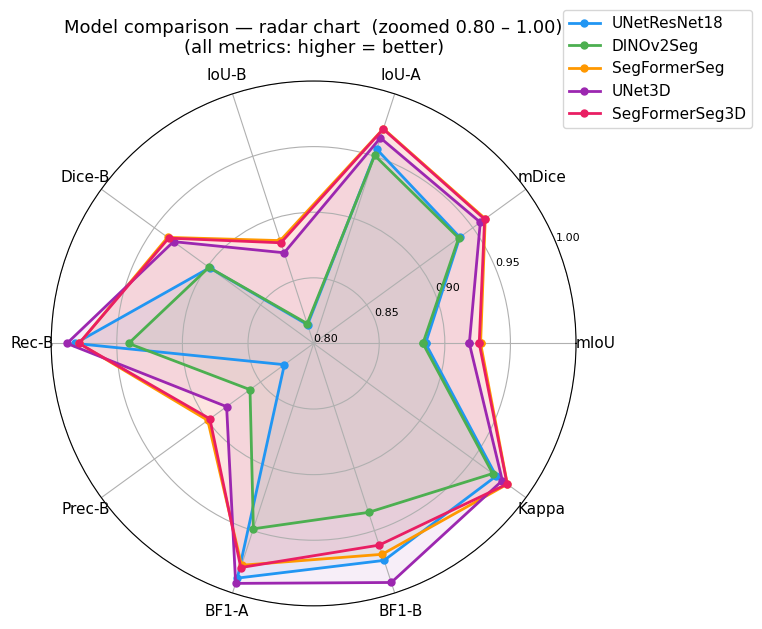

In [8]:
# ── 7. Radar / spider chart ───────────────────────────────────────────────────
radar_keys   = ['mIoU', 'mDice', 'IoU-A', 'IoU-B', 'Dice-B',
                 'Rec-B', 'Prec-B', 'BF1-A', 'BF1-B', 'Kappa']

def get_radar_vals(name):
    m, b = RESULTS[name]['mets'], RESULTS[name]['bf1']
    return [
        m['mean_iou'], m['mean_dice'],
        m['iou'][1], m['iou'][2], m['dice'][2],
        m['recall'][2], m['precision'][2],
        b[1], b[2], m['kappa'],
    ]

# Zoom bounds — set to just below the minimum observed score so the
# centre of the chart is meaningful rather than wasted at 0.
RADAR_MIN = 0.80   # adjust if any metric falls below this
RADAR_MAX = 1.00

N     = len(radar_keys)
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
theta = np.concatenate([theta, [theta[0]]])   # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for name, model in MODELS.items():
    vals = get_radar_vals(name) + [get_radar_vals(name)[0]]
    ax.plot(theta, vals, '-o', label=name, color=MODEL_SPECS[name]['color'], lw=2, ms=5)
    ax.fill(theta, vals, alpha=0.08, color=MODEL_SPECS[name]['color'])

ax.set_thetagrids(np.degrees(theta[:-1]), radar_keys, fontsize=11)
ax.set_ylim(RADAR_MIN, RADAR_MAX)
ax.set_yticks(np.arange(RADAR_MIN, RADAR_MAX + 0.001, 0.05))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.yaxis.set_tick_params(labelsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.set_title(
    f'Model comparison — radar chart  (zoomed {RADAR_MIN:.2f} – {RADAR_MAX:.2f})\n'
    '(all metrics: higher = better)',
    fontsize=13, pad=20,
)
plt.tight_layout()
plt.show()

In [9]:
# ── 8. Inference speed benchmark ─────────────────────────────────────────────
# Use a single 256×255 grayscale image (native res) for all 2D models.
# For UNet3D we use a 5-slice stack at the same H×W.
BENCH_RUNS   = 20
BENCH_WARMUP = 5
H_NAT, W_NAT = 256, 255

bench_results = {}
for name, model in MODELS.items():
    spec = MODEL_SPECS[name]
    if spec['mode'] == '2d':
        sz = spec['img_size']
        dummy = torch.randn(1, 1, sz[0], sz[1])
    else:
        sz    = spec['img_size']
        depth = spec['depth']
        dummy = torch.randn(1, 1, depth, sz[0], sz[1])
    t = benchmark_inference(model, dummy, BENCH_WARMUP, BENCH_RUNS)
    ram = peak_ram_mb(model, dummy)
    ckpt_mb = os.path.getsize(spec['ckpt']) / 1024**2
    n_total = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    bench_results[name] = dict(**t, ram_mb=ram, ckpt_mb=ckpt_mb,
                               n_total=n_total, n_train=n_train)
    print(f'{name:15s}  {t["mean"]:6.1f} ± {t["std"]:4.1f} ms  '
          f'p95={t["p95"]:5.1f} ms  {t["fps"]:5.1f} FPS  '
          f'RAM={ram:.1f} MB  ckpt={ckpt_mb:.1f} MB  '
          f'params={n_total/1e6:.1f}M ({n_train/1e6:.1f}M trainable)')

UNetResNet18       79.7 ± 30.6 ms  p95=101.9 ms   12.6 FPS  RAM=0.0 MB  ckpt=55.1 MB  params=14.4M (14.4M trainable)
DINOv2Seg         185.3 ± 18.2 ms  p95=228.1 ms    5.4 FPS  RAM=0.0 MB  ckpt=86.7 MB  params=22.7M (0.7M trainable)
SegFormerSeg      205.4 ± 49.3 ms  p95=304.0 ms    4.9 FPS  RAM=0.0 MB  ckpt=61.0 MB  params=16.0M (2.8M trainable)
UNet3D            299.3 ± 20.7 ms  p95=331.2 ms    3.3 FPS  RAM=0.0 MB  ckpt=4.1 MB  params=1.1M (1.1M trainable)
SegFormerSeg3D    481.8 ± 46.4 ms  p95=586.0 ms    2.1 FPS  RAM=0.0 MB  ckpt=61.0 MB  params=16.0M (2.8M trainable)


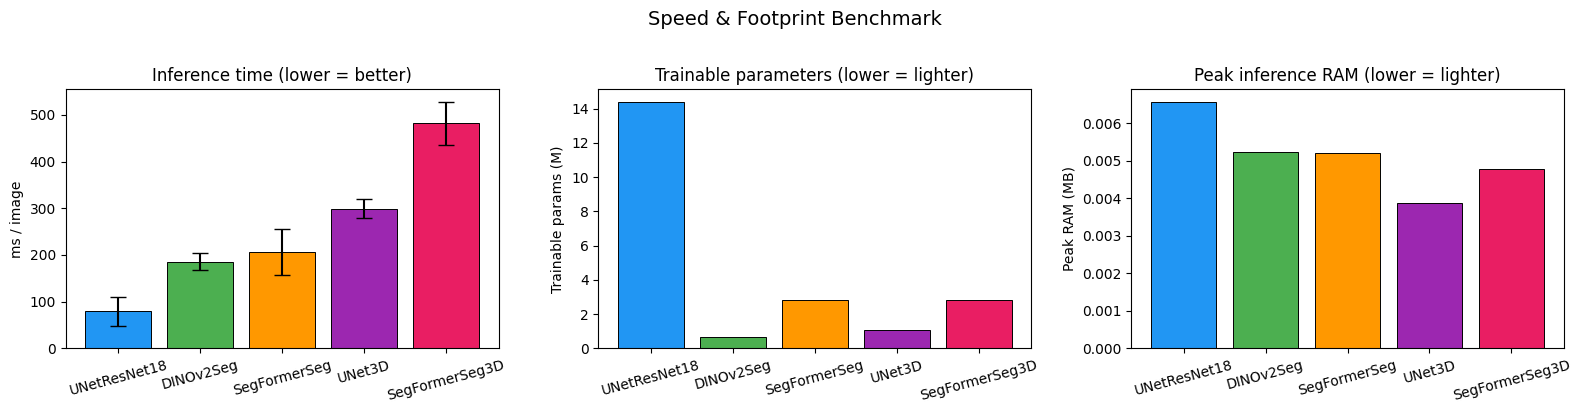

In [10]:
# ── 9. Speed + footprint plots ────────────────────────────────────────────────
names  = list(bench_results)
colors = [MODEL_SPECS[n]['color'] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Inference time
means = [bench_results[n]['mean'] for n in names]
stds  = [bench_results[n]['std']  for n in names]
axes[0].bar(names, means, yerr=stds, color=colors, capsize=6, edgecolor='k', linewidth=0.7)
axes[0].set_ylabel('ms / image'); axes[0].set_title('Inference time (lower = better)')
axes[0].tick_params(axis='x', rotation=15)

# (b) Trainable parameters
n_tr = [bench_results[n]['n_train']/1e6 for n in names]
axes[1].bar(names, n_tr, color=colors, edgecolor='k', linewidth=0.7)
axes[1].set_ylabel('Trainable params (M)'); axes[1].set_title('Trainable parameters (lower = lighter)')
axes[1].tick_params(axis='x', rotation=15)

# (c) Peak inference RAM
rams = [bench_results[n]['ram_mb'] for n in names]
axes[2].bar(names, rams, color=colors, edgecolor='k', linewidth=0.7)
axes[2].set_ylabel('Peak RAM (MB)'); axes[2].set_title('Peak inference RAM (lower = lighter)')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Speed & Footprint Benchmark', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

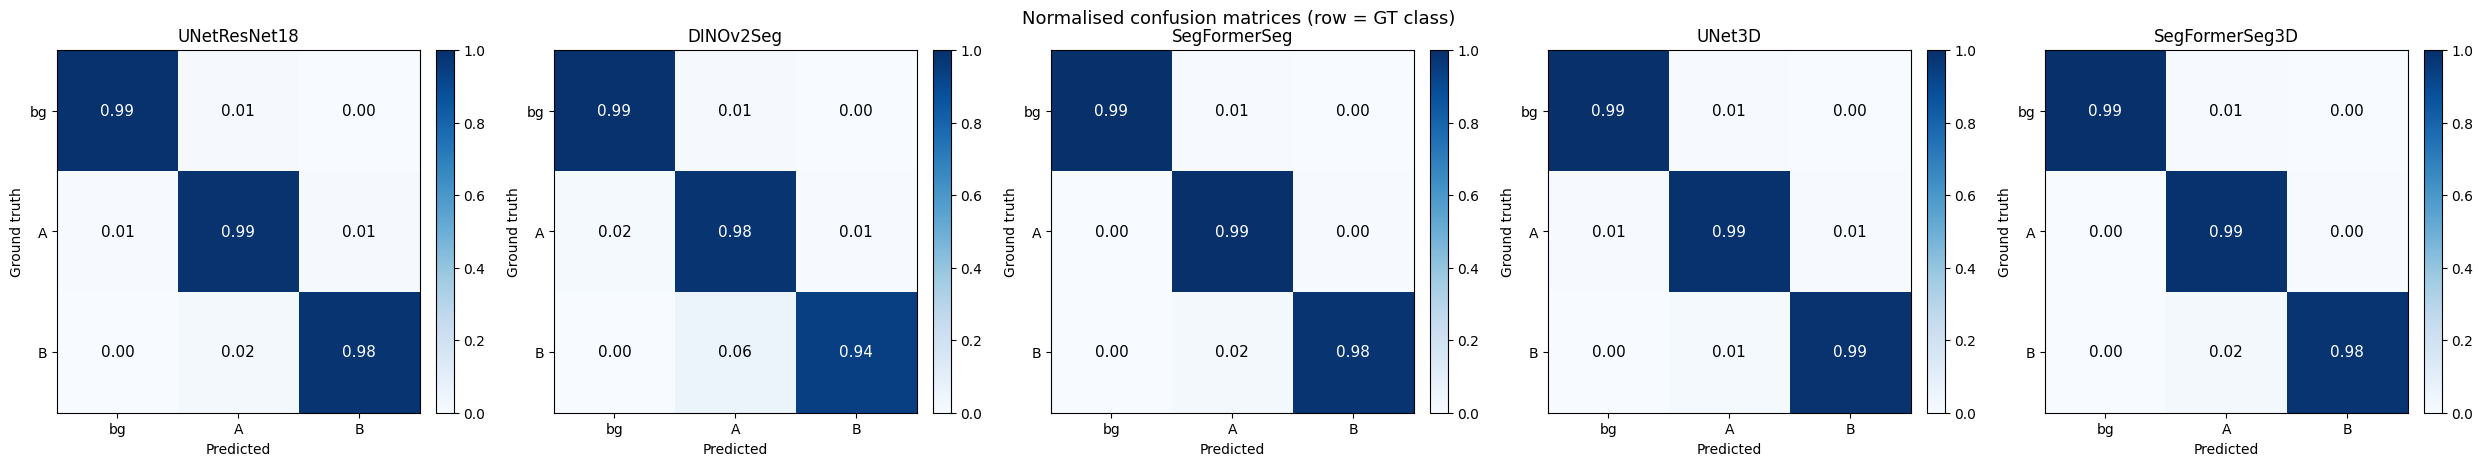

In [11]:
# ── 10. Confusion matrices ────────────────────────────────────────────────────
n_models = len(RESULTS)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, RESULTS.items()):
    cm_raw = res['cm'].astype(float)
    cm_norm = cm_raw / (cm_raw.sum(axis=1, keepdims=True) + 1e-8)  # row-normalised
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(['bg', 'A', 'B']); ax.set_yticklabels(['bg', 'A', 'B'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground truth')
    ax.set_title(name)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Normalised confusion matrices (row = GT class)', fontsize=13)
plt.tight_layout()
plt.show()

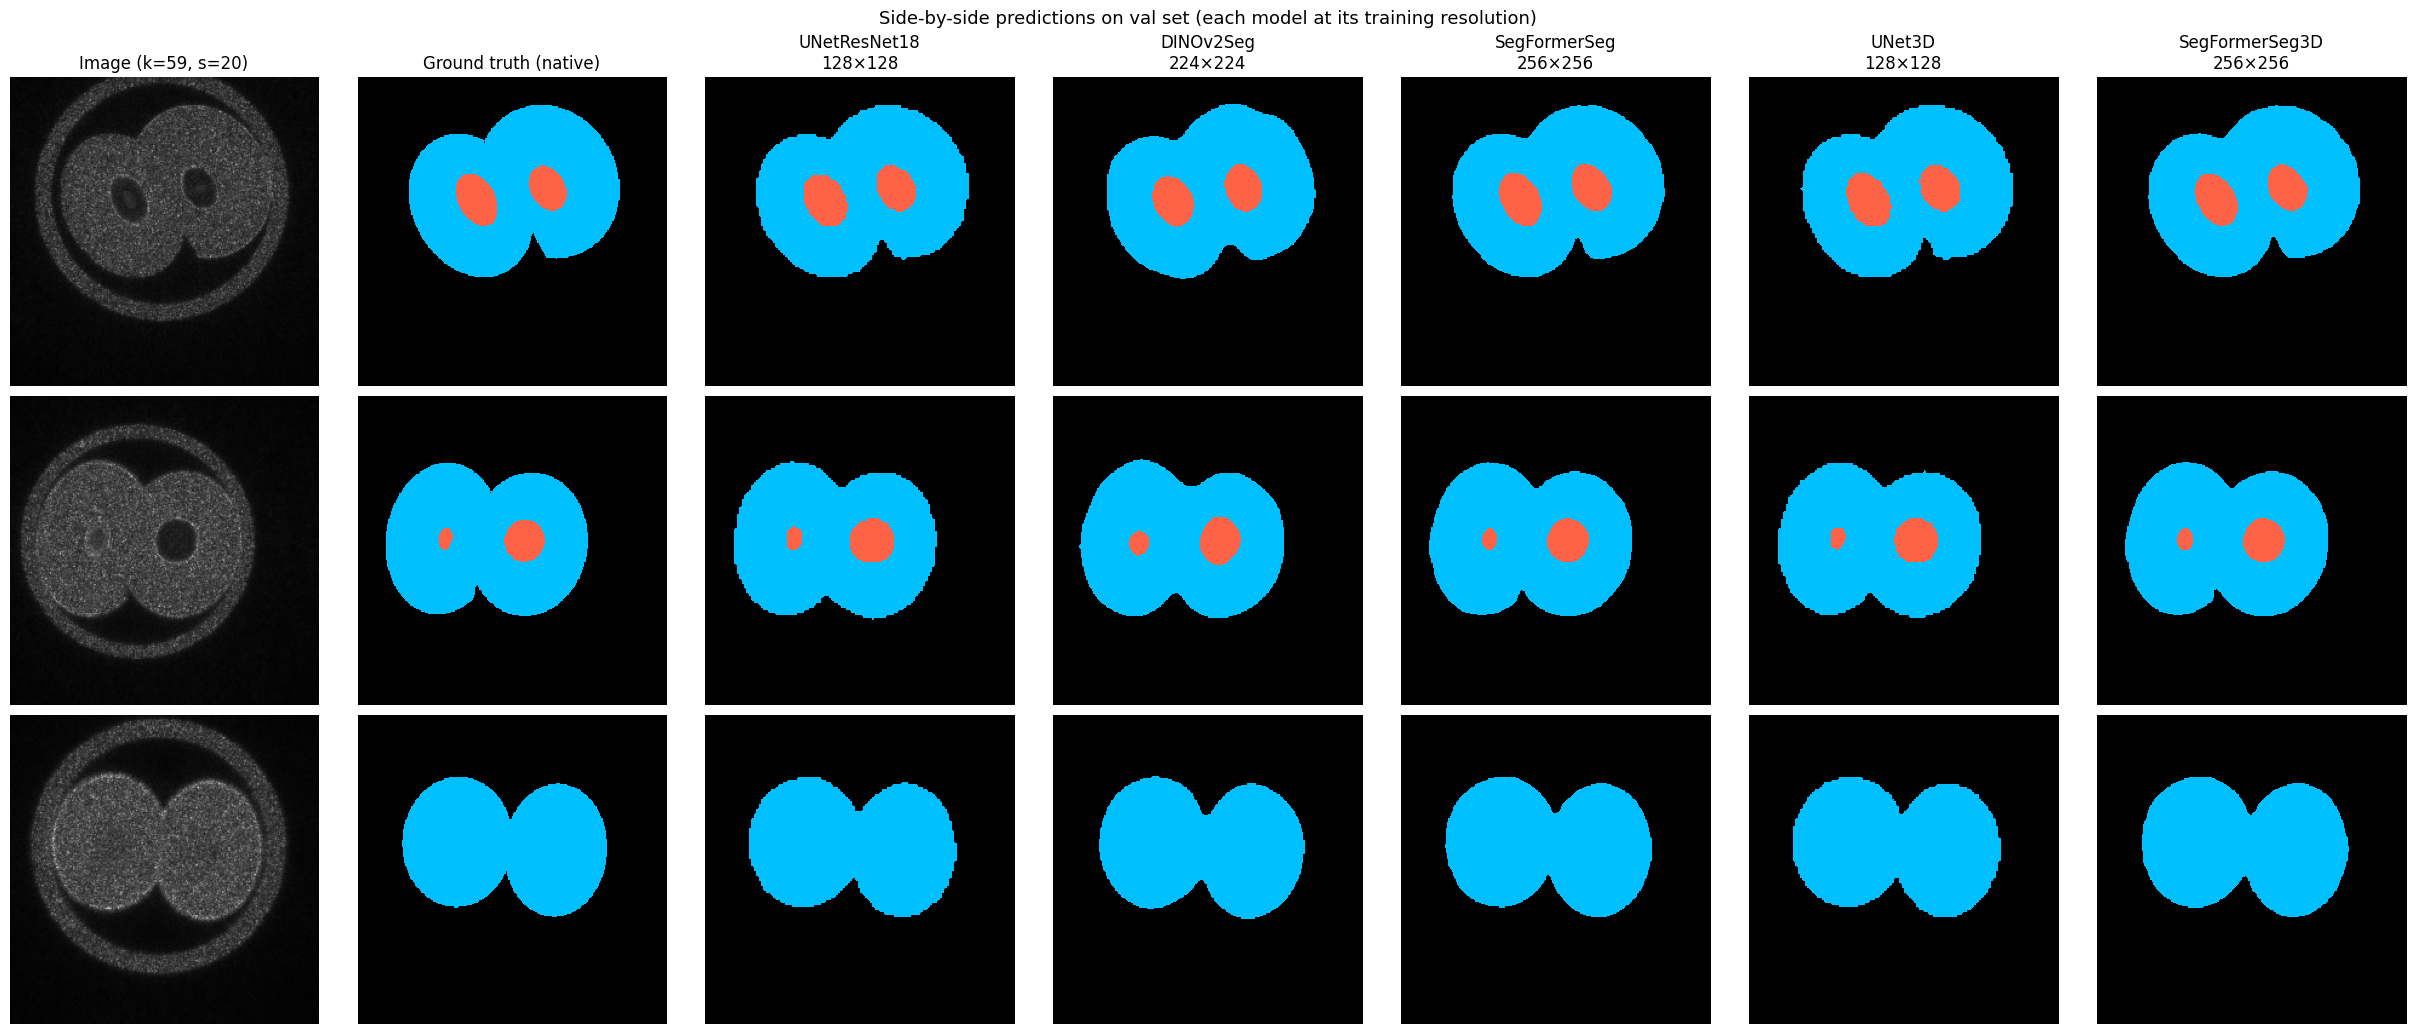

In [12]:
# ── 11. Side-by-side visual comparison ───────────────────────────────────────
# Each model's prediction shown at its training resolution.
# GT is resized to the same resolution so the display is apples-to-apples.
VIS_SAMPLES = [(VAL_K[0], 20), (VAL_K[3], 30), (VAL_K[7], 40)]
model_names  = list(MODELS)
n_cols = 2 + len(MODELS)   # Image + GT + one per model

fig, axes = plt.subplots(len(VIS_SAMPLES), n_cols,
                          figsize=(3.5 * n_cols, 3.5 * len(VIS_SAMPLES)))

for row, (k, s) in enumerate(VIS_SAMPLES):
    img_native = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k}.tif'))[s].astype(np.float32) / 255.0
    gt_native  = process_mask(load_tif_stack(os.path.join(DATA_DIR, f'mask_{k}.tif'))[s])

    # Show image and GT at native resolution in the first two columns
    axes[row, 0].imshow(img_native, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'Image (k={k}, s={s})' if row == 0 else '')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(gt_native, cmap=CMAP, vmin=0, vmax=2)
    axes[row, 1].set_title('Ground truth (native)' if row == 0 else '')
    axes[row, 1].axis('off')

    for col, name in enumerate(model_names, start=2):
        spec  = MODEL_SPECS[name]
        model = MODELS[name]
        sz    = spec['img_size']
        if spec['mode'] == '2d':
            pred = predict_slice(model, img_native, DEVICE, img_size=sz)
        else:
            n_sl = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).shape[0]
            iv   = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).astype(np.float32)/255.
            half = spec['depth'] // 2
            ids  = [max(0, min(n_sl-1, s+d-half)) for d in range(spec['depth'])]
            pred = predict_slice_3d(model, np.stack([iv[i] for i in ids]), DEVICE, img_size=sz)
        axes[row, col].imshow(pred, cmap=CMAP, vmin=0, vmax=2)
        title = f'{name}\n{sz[0]}×{sz[1]}' if row == 0 else ''
        axes[row, col].set_title(title)
        axes[row, col].axis('off')

plt.suptitle('Side-by-side predictions on val set (each model at its training resolution)', fontsize=13)
plt.tight_layout()
plt.show()

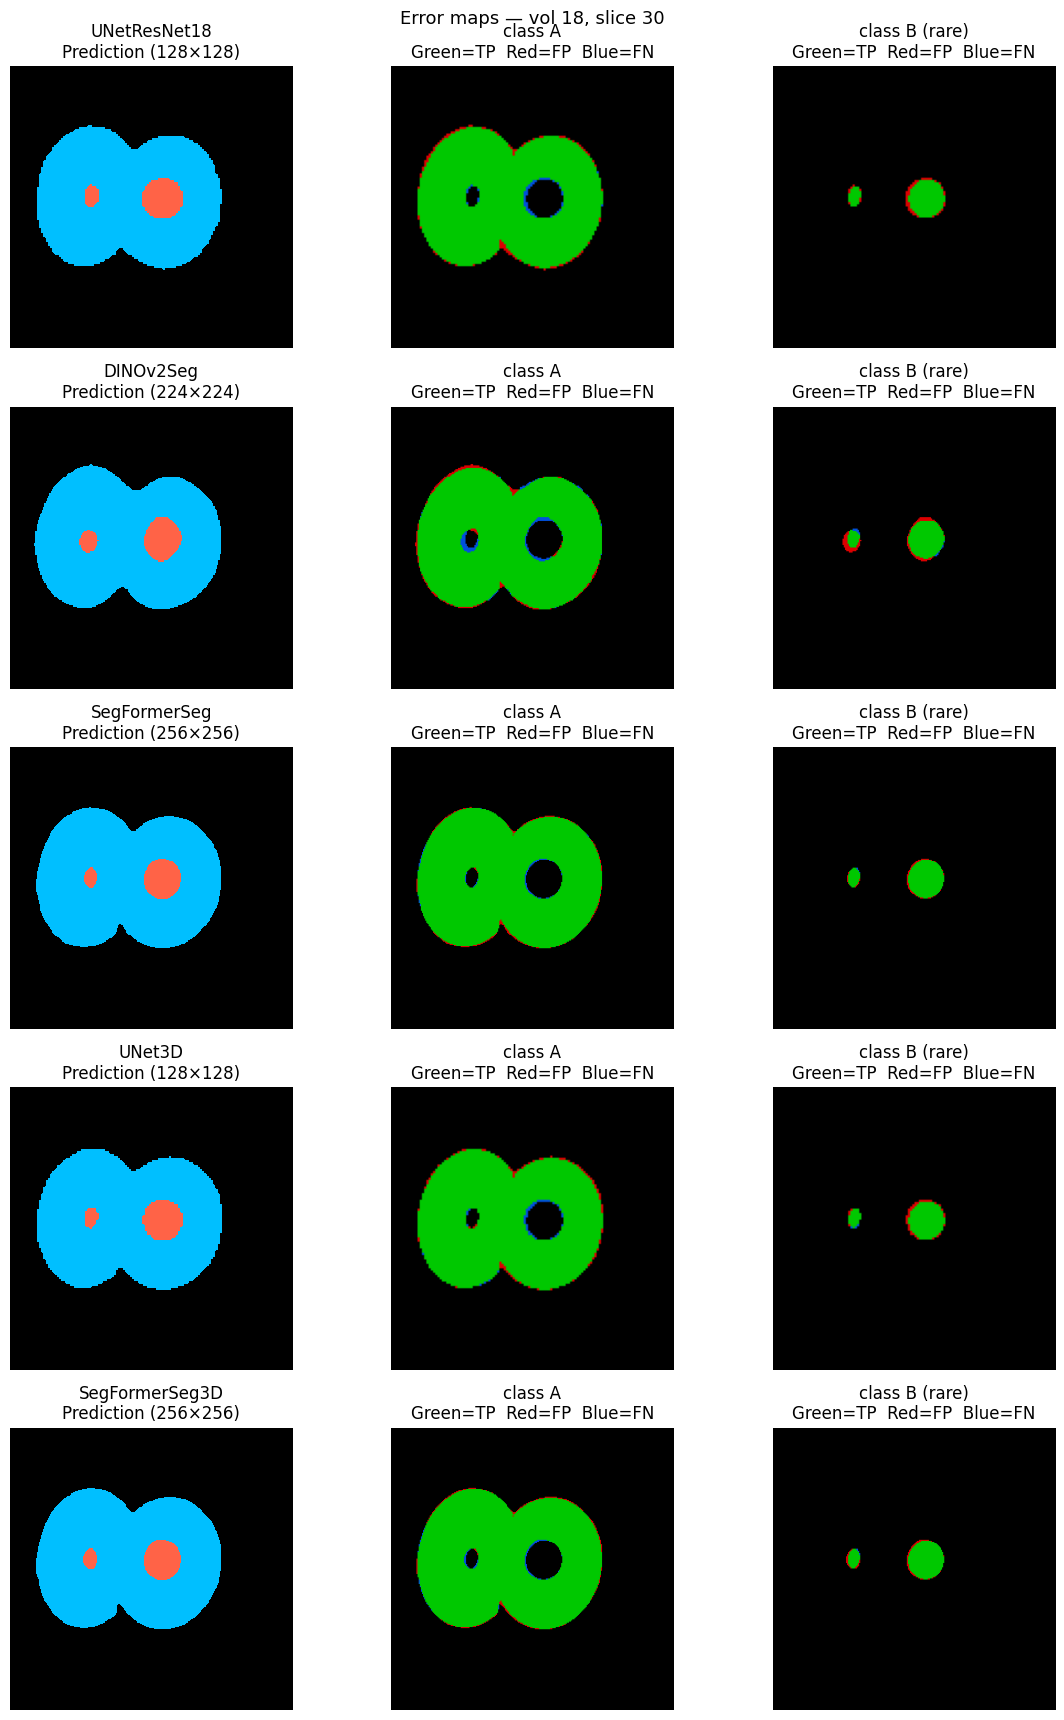

In [13]:
# ── 12. Error maps ─────────────────────────────────────────────────────────────
# Green = correct, Red = false positive, Blue = false negative (per foreground class)
# GT is resized to match each model's training resolution so shapes always agree.
k_err, s_err = VIS_SAMPLES[1]   # use the middle sample
img_e      = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k_err}.tif'))[s_err].astype(np.float32)/255.
gt_e_native = process_mask(load_tif_stack(os.path.join(DATA_DIR, f'mask_{k_err}.tif'))[s_err])

fig, axes = plt.subplots(len(MODELS), 3, figsize=(12, 3.5 * len(MODELS)))
if len(MODELS) == 1:
    axes = axes[np.newaxis, :]

fg_classes  = [1, 2]
class_names = {1: 'class A', 2: 'class B (rare)'}

for row, name in enumerate(MODELS):
    spec  = MODEL_SPECS[name]
    model = MODELS[name]
    sz    = spec['img_size']
    # GT at model's training resolution
    gt_e = resize_gt(gt_e_native, sz) if sz is not None else gt_e_native

    if spec['mode'] == '2d':
        pred_e = predict_slice(model, img_e, DEVICE, img_size=sz)
    else:
        iv   = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k_err}.tif')).astype(np.float32)/255.
        n_sl = iv.shape[0]
        half = spec['depth'] // 2
        ids  = [max(0, min(n_sl-1, s_err+d-half)) for d in range(spec['depth'])]
        pred_e = predict_slice_3d(model, np.stack([iv[i] for i in ids]), DEVICE, img_size=sz)

    axes[row, 0].imshow(pred_e, cmap=CMAP, vmin=0, vmax=2)
    axes[row, 0].set_title(f'{name}\nPrediction ({sz[0]}×{sz[1]})')
    axes[row, 0].axis('off')

    for col, cls in enumerate(fg_classes, start=1):
        err_map = np.zeros((*gt_e.shape, 3), dtype=np.uint8)
        tp_mask = (pred_e == cls) & (gt_e == cls)
        fp_mask = (pred_e == cls) & (gt_e != cls)
        fn_mask = (pred_e != cls) & (gt_e == cls)
        err_map[tp_mask] = [0, 200, 0]     # green  – true positive
        err_map[fp_mask] = [220, 0, 0]     # red    – false positive
        err_map[fn_mask] = [0, 80, 220]    # blue   – false negative
        axes[row, col].imshow(err_map)
        axes[row, col].set_title(f'{class_names[cls]}\nGreen=TP  Red=FP  Blue=FN')
        axes[row, col].axis('off')

plt.suptitle(f'Error maps — vol {k_err}, slice {s_err}', fontsize=13)
plt.tight_layout()
plt.show()

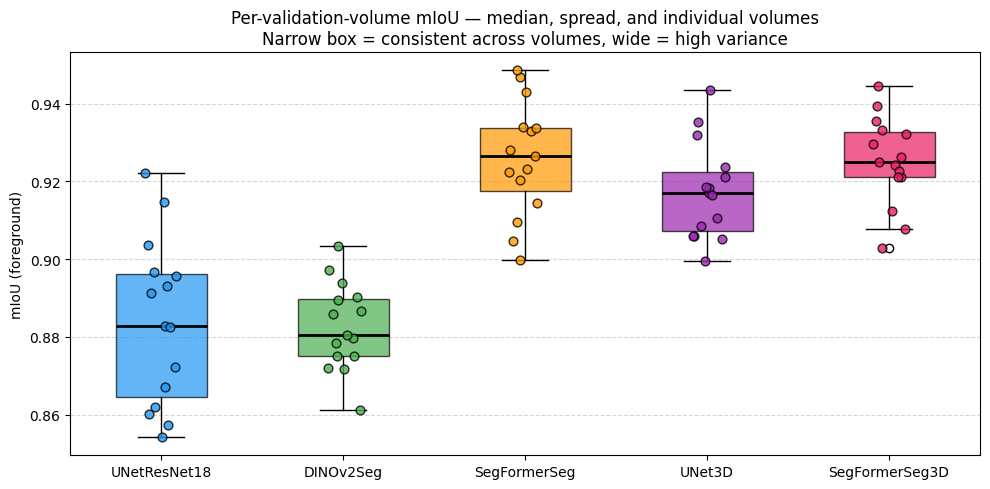


Per-volume mIoU statistics:
Model              mean    std    min    max
UNetResNet18     0.8837 0.0205 0.8543 0.9222
DINOv2Seg        0.8827 0.0107 0.8612 0.9033
SegFormerSeg     0.9259 0.0142 0.8998 0.9485
UNet3D           0.9174 0.0119 0.8994 0.9435
SegFormerSeg3D   0.9252 0.0110 0.9029 0.9444


In [14]:
# ── 13. Per-volume mIoU box plots (consistency) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

data_box   = [RESULTS[n]['per_vol_miou'] for n in RESULTS]
colors_box = [MODEL_SPECS[n]['color'] for n in RESULTS]
labels_box = list(RESULTS)

bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Overlay individual points
for i, (d, c) in enumerate(zip(data_box, colors_box), start=1):
    ax.scatter(np.full(len(d), i) + np.random.uniform(-0.1, 0.1, len(d)),
               d, color=c, edgecolors='k', s=40, zorder=5, alpha=0.8)

ax.set_xticks(range(1, len(labels_box)+1))
ax.set_xticklabels(labels_box)
ax.set_ylabel('mIoU (foreground)')
ax.set_title('Per-validation-volume mIoU — median, spread, and individual volumes\n'
             'Narrow box = consistent across volumes, wide = high variance')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\nPer-volume mIoU statistics:')
print(f'{"Model":<16} {"mean":>6} {"std":>6} {"min":>6} {"max":>6}')
for n in RESULTS:
    v = RESULTS[n]['per_vol_miou']
    print(f'{n:<16} {np.mean(v):6.4f} {np.std(v):6.4f} {np.min(v):6.4f} {np.max(v):6.4f}')

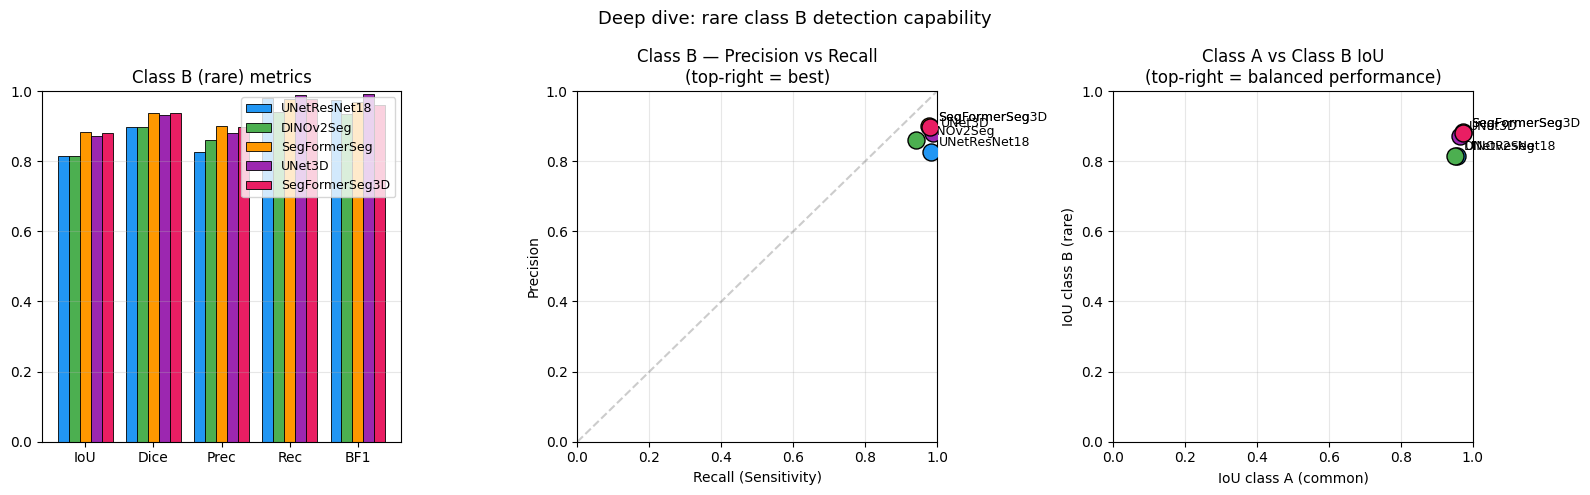

In [15]:
# ── 14. Class B (rare, ~1%) deep dive ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names  = list(RESULTS)
colors_list  = [MODEL_SPECS[n]['color'] for n in model_names]

metrics_B = {n: {
    'IoU'  : RESULTS[n]['mets']['iou'][2],
    'Dice' : RESULTS[n]['mets']['dice'][2],
    'Prec' : RESULTS[n]['mets']['precision'][2],
    'Rec'  : RESULTS[n]['mets']['recall'][2],
    'BF1'  : RESULTS[n]['bf1'][2],
} for n in model_names}

sub_metrics = ['IoU', 'Dice', 'Prec', 'Rec', 'BF1']
x = np.arange(len(sub_metrics))
bar_w = 0.8 / len(model_names)

for i, (name, color) in enumerate(zip(model_names, colors_list)):
    vals = [metrics_B[name][m] for m in sub_metrics]
    axes[0].bar(x + i*bar_w - 0.4 + bar_w/2, vals, bar_w,
                label=name, color=color, edgecolor='k', linewidth=0.6)
axes[0].set_xticks(x); axes[0].set_xticklabels(sub_metrics)
axes[0].set_ylim(0, 1); axes[0].legend(fontsize=9)
axes[0].set_title('Class B (rare) metrics')
axes[0].grid(axis='y', alpha=0.3)

# Precision–Recall scatter for class B
for name, color in zip(model_names, colors_list):
    axes[1].scatter(RESULTS[name]['mets']['recall'][2],
                    RESULTS[name]['mets']['precision'][2],
                    s=150, color=color, zorder=5, edgecolors='k', label=name)
    axes[1].annotate(name, (RESULTS[name]['mets']['recall'][2],
                             RESULTS[name]['mets']['precision'][2]),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[1].set_xlabel('Recall (Sensitivity)'); axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].plot([0,1],[0,1],'--', color='grey', alpha=0.4)   # iso-F1 diagonal guide
axes[1].set_title('Class B — Precision vs Recall\n(top-right = best)')
axes[1].grid(alpha=0.3)

# Class B vs Class A IoU
for name, color in zip(model_names, colors_list):
    axes[2].scatter(RESULTS[name]['mets']['iou'][1],
                    RESULTS[name]['mets']['iou'][2],
                    s=150, color=color, zorder=5, edgecolors='k', label=name)
    axes[2].annotate(name, (RESULTS[name]['mets']['iou'][1],
                             RESULTS[name]['mets']['iou'][2]),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[2].set_xlabel('IoU class A (common)'); axes[2].set_ylabel('IoU class B (rare)')
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
axes[2].set_title('Class A vs Class B IoU\n(top-right = balanced performance)')
axes[2].grid(alpha=0.3)

plt.suptitle('Deep dive: rare class B detection capability', fontsize=13)
plt.tight_layout()
plt.show()

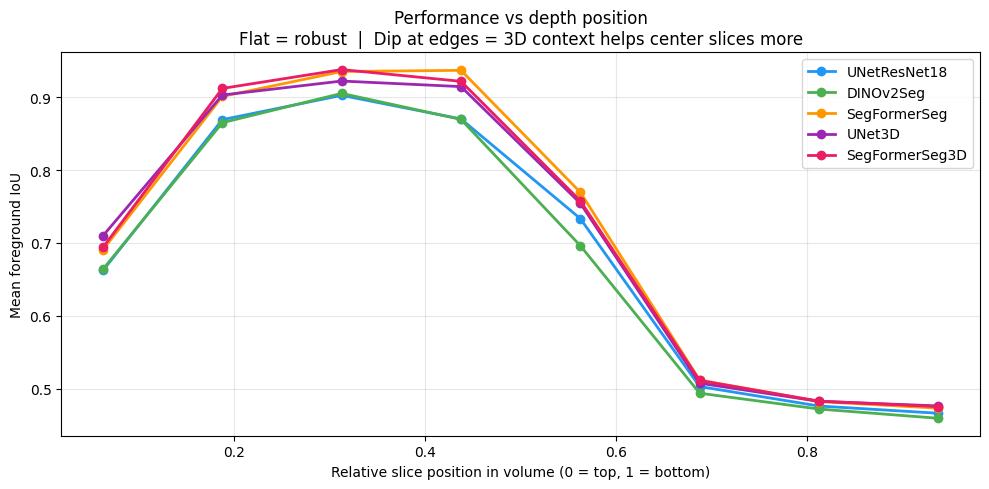

In [16]:
# ── 15. Performance vs slice depth position ───────────────────────────────────
# Does performance degrade at the top/bottom of a volume (edge slices)?
N_BINS = 8
bins   = np.linspace(0, 1, N_BINS + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(figsize=(10, 5))

for name in RESULTS:
    depths_ious = RESULTS[name]['per_slice_depths']  # list of (frac, iou)
    fracs = np.array([x[0] for x in depths_ious])
    ious  = np.array([x[1] for x in depths_ious])
    bin_means = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (fracs >= lo) & (fracs < hi)
        bin_means.append(ious[mask].mean() if mask.sum() > 0 else np.nan)
    ax.plot(bin_centers, bin_means, '-o', label=name,
            color=MODEL_SPECS[name]['color'], lw=2, ms=6)

ax.set_xlabel('Relative slice position in volume (0 = top, 1 = bottom)')
ax.set_ylabel('Mean foreground IoU')
ax.set_title('Performance vs depth position\n'
             'Flat = robust  |  Dip at edges = 3D context helps center slices more')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ── 16. Final ranking table ───────────────────────────────────────────────────
print('=' * 70)
print('FINAL RANKING SUMMARY')
print('=' * 70)

ranking_metrics = [
    ('mIoU (fg)',          lambda n: RESULTS[n]['mets']['mean_iou']),
    ('mDice (fg)',         lambda n: RESULTS[n]['mets']['mean_dice']),
    ('IoU class B (rare)', lambda n: RESULTS[n]['mets']['iou'][2]),
    ('Boundary-F1 (fg avg)',lambda n: RESULTS[n]['bf1'][1:].mean()),
    ('Kappa',              lambda n: RESULTS[n]['mets']['kappa']),
    ('Speed (FPS)',         lambda n: bench_results[n]['fps'] if n in bench_results else 0),
    ('Consistency (1-std)', lambda n: 1 - np.std(RESULTS[n]['per_vol_miou'])),
]

for metric_name, fn in ranking_metrics:
    vals = {n: fn(n) for n in RESULTS}
    ranked = sorted(vals, key=vals.get, reverse=True)
    print(f'\n{metric_name}:')
    for rank, n in enumerate(ranked, 1):
        marker = ' ◀ BEST' if rank == 1 else ''
        print(f'  {rank}. {n:<16}  {vals[n]:.4f}{marker}')

# Overall score: average rank across all quality metrics (excluding speed)
print('\n' + '─' * 70)
quality_fns = [fn for _, fn in ranking_metrics[:-2]]  # exclude speed + consistency
score = {}
for n in RESULTS:
    ranks = []
    for fn in quality_fns:
        vals = {m: fn(m) for m in RESULTS}
        sorted_names = sorted(vals, key=vals.get, reverse=True)
        ranks.append(sorted_names.index(n) + 1)
    score[n] = np.mean(ranks)

print('\nOverall quality rank (lower avg rank = better):')
for n in sorted(score, key=score.get):
    print(f'  {n:<16}  avg rank = {score[n]:.2f}')
print('=' * 70)

FINAL RANKING SUMMARY

mIoU (fg):
  1. SegFormerSeg      0.9273 ◀ BEST
  2. SegFormerSeg3D    0.9262
  3. UNet3D            0.9187
  4. UNetResNet18      0.8853
  5. DINOv2Seg         0.8833

mDice (fg):
  1. SegFormerSeg      0.9617 ◀ BEST
  2. SegFormerSeg3D    0.9611
  3. UNet3D            0.9570
  4. UNetResNet18      0.9377
  5. DINOv2Seg         0.9367

IoU class B (rare):
  1. SegFormerSeg      0.8824 ◀ BEST
  2. SegFormerSeg3D    0.8806
  3. UNet3D            0.8726
  4. DINOv2Seg         0.8159
  5. UNetResNet18      0.8150

Boundary-F1 (fg avg):
  1. UNet3D            0.9919 ◀ BEST
  2. UNetResNet18      0.9810
  3. SegFormerSeg      0.9734
  4. SegFormerSeg3D    0.9706
  5. DINOv2Seg         0.9420

Kappa:
  1. SegFormerSeg      0.9825 ◀ BEST
  2. SegFormerSeg3D    0.9823
  3. UNet3D            0.9778
  4. UNetResNet18      0.9720
  5. DINOv2Seg         0.9687

Speed (FPS):
  1. UNetResNet18      12.5540 ◀ BEST
  2. DINOv2Seg         5.3963
  3. SegFormerSeg      4.8683
  4.

---
## 17 · Depth / Spatial Coherence

A segmentation model should produce **consistent predictions across consecutive slices**: a cell
that exists in slice *s* should still appear (roughly the same shape) in slice *s+1*.
2-D models see each slice in isolation — they have no incentive to be coherent across depth.
3-D models (UNet3D, SegFormerSeg3D) explicitly see neighbouring slices, so we expect them
to score better here.

Three complementary metrics, each run on **all slices (stride = 1)** of `COH_VAL_K` volumes:

| Metric | What it measures | Ideal value |
|---|---|---|
| **Slice-to-slice IoU** (SS-IoU) | Overlap of consecutive predicted masks for the same class | ≈ GT SS-IoU (match data coherence) |
| **Spurious flip rate** | Among pixels where **GT did not change** between slices, fraction that the model predicts differently. The raw flip rate is not meaningful (cells naturally appear/disappear — it's never near 0) | 0 |
| **Error map consistency** | IoU of consecutive error maps `(pred≠gt)` across slices. High = model makes mistakes in the same spatial locations consistently (coherent in its errors). Low = errors flicker randomly slice-to-slice | High |
| **3-D connected-components ratio** | Pred 3-D CCs / GT 3-D CCs per class | 1 (>1 = fragmented, <1 = merged) |

In [18]:
# ── 17. Depth / spatial coherence ────────────────────────────────────────────
# Runs stride=1 (every slice) to get proper consecutive pairs.
# Uses a subset of val volumes to keep runtime reasonable.
from scipy.ndimage import label as nd_label

COH_VAL_K = VAL_K[:5]   # 5 volumes × ~61 slices = ~305 predictions per model
print(f'Coherence volumes: {COH_VAL_K}\n')

COHERENCE = {}   # name → dict of metrics

for name, model in MODELS.items():
    spec  = MODEL_SPECS[name]
    mode  = spec['mode']
    sz    = spec['img_size']
    depth = spec.get('depth', DEPTH_3D)
    half  = depth // 2

    # Accumulators
    ss_iou_A_pred, ss_iou_B_pred = [], []   # slice-to-slice IoU from predictions
    ss_iou_A_gt,   ss_iou_B_gt   = [], []   # same metric on GT (reference)
    spurious_flip_list   = []               # per-volume spurious flip rates
    err_consistency_list = []               # per-volume error map consistency
    cc_ratio_A_list, cc_ratio_B_list = [], []   # per-volume 3-D CC ratios

    print(f'  {name} …')
    with torch.no_grad():
        for k in tqdm(COH_VAL_K, desc=f'  {name}', leave=False):
            img_vol  = load_tif_stack(
                os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).astype(np.float32) / 255.0
            msk_vol  = load_tif_stack(os.path.join(DATA_DIR, f'mask_{k}.tif'))
            n_slices = img_vol.shape[0]

            pred_vol, gt_vol = [], []

            for s in range(n_slices):   # stride = 1 — every slice
                gt_nat = process_mask(msk_vol[s])
                gt_s   = resize_gt(gt_nat, sz) if sz is not None else gt_nat

                if mode == '2d':
                    pred_s = predict_slice(model, img_vol[s], DEVICE, img_size=sz)
                else:
                    ids   = [max(0, min(n_slices-1, s+d-half)) for d in range(depth)]
                    patch = np.stack([img_vol[i] for i in ids])
                    pred_s = predict_slice_3d(model, patch, DEVICE, img_size=sz)

                pred_vol.append(pred_s)
                gt_vol.append(gt_s)

            pred_vol = np.stack(pred_vol)   # (N, H, W) int
            gt_vol   = np.stack(gt_vol)     # (N, H, W) int

            # ── 1. Slice-to-slice IoU ─────────────────────────────────────────
            for s in range(n_slices - 1):
                for c, sp, sg in [
                    (1, ss_iou_A_pred, ss_iou_A_gt),
                    (2, ss_iou_B_pred, ss_iou_B_gt),
                ]:
                    # prediction
                    inter = ((pred_vol[s] == c) & (pred_vol[s+1] == c)).sum()
                    union = ((pred_vol[s] == c) | (pred_vol[s+1] == c)).sum()
                    sp.append(float(inter / (union + 1e-8)))
                    # ground truth (reference coherence of the data itself)
                    inter_g = ((gt_vol[s] == c) & (gt_vol[s+1] == c)).sum()
                    union_g = ((gt_vol[s] == c) | (gt_vol[s+1] == c)).sum()
                    sg.append(float(inter_g / (union_g + 1e-8)))

            # ── 2. Spurious flip rate & error map consistency ─────────────────
            # Spurious flip: prediction changes on pixels where GT did NOT change.
            # Raw flip rate is uninformative (cells naturally appear/disappear).
            # Error consistency: IoU of consecutive error maps (pred≠gt).
            sf_pairs, ec_pairs = [], []
            for s in range(n_slices - 1):
                # Pixels where GT is stable between slices s and s+1
                stable   = (gt_vol[s] == gt_vol[s+1])
                n_stable = int(stable.sum())
                if n_stable > 0:
                    spurious = int(((pred_vol[s] != pred_vol[s+1]) & stable).sum())
                    sf_pairs.append(spurious / n_stable)

                # Error maps: where does each slice's prediction disagree with GT?
                err_s  = (pred_vol[s]   != gt_vol[s])
                err_s1 = (pred_vol[s+1] != gt_vol[s+1])
                union_e = int((err_s | err_s1).sum())
                if union_e > 0:
                    ec_pairs.append(int((err_s & err_s1).sum()) / union_e)
                else:
                    ec_pairs.append(1.0)   # both maps empty = perfect consistency

            spurious_flip_list.append(float(np.mean(sf_pairs)) if sf_pairs else 0.0)
            err_consistency_list.append(float(np.mean(ec_pairs)) if ec_pairs else 0.0)

            # ── 3. 3-D connected components ───────────────────────────────────
            for c, store in [(1, cc_ratio_A_list), (2, cc_ratio_B_list)]:
                _, n_pred_cc = nd_label(pred_vol == c)
                _, n_gt_cc   = nd_label(gt_vol   == c)
                if n_gt_cc > 0:
                    store.append(n_pred_cc / n_gt_cc)

    COHERENCE[name] = {
        'ss_iou_A'        : float(np.mean(ss_iou_A_pred)),
        'ss_iou_B'        : float(np.mean(ss_iou_B_pred)),
        'ss_iou_A_gt'     : float(np.mean(ss_iou_A_gt)),
        'ss_iou_B_gt'     : float(np.mean(ss_iou_B_gt)),
        'spurious_flip'   : float(np.mean(spurious_flip_list)),
        'err_consistency' : float(np.mean(err_consistency_list)),
        'cc_ratio_A'      : float(np.mean(cc_ratio_A_list)) if cc_ratio_A_list else float('nan'),
        'cc_ratio_B'      : float(np.mean(cc_ratio_B_list)) if cc_ratio_B_list else float('nan'),
    }
    c = COHERENCE[name]
    print(f'    SS-IoU  A={c["ss_iou_A"]:.4f} (GT={c["ss_iou_A_gt"]:.4f})  '
          f'B={c["ss_iou_B"]:.4f} (GT={c["ss_iou_B_gt"]:.4f})')
    print(f'    spurious_flip={c["spurious_flip"]:.5f}  '
          f'err_consistency={c["err_consistency"]:.4f}  '
          f'CC-ratio  A={c["cc_ratio_A"]:.3f}  B={c["cc_ratio_B"]:.3f}')

print('\nCoherence analysis complete.')


Coherence volumes: [59, 21, 56, 18, 33]

  UNetResNet18 …


    SS-IoU  A=0.9686 (GT=0.9700)  B=0.4576 (GT=0.4555)
    spurious_flip=0.00414  err_consistency=0.4132  CC-ratio  A=1.000  B=1.200
  DINOv2Seg …


    SS-IoU  A=0.9651 (GT=0.9700)  B=0.4360 (GT=0.4560)
    spurious_flip=0.00515  err_consistency=0.4200  CC-ratio  A=1.000  B=1.100
  SegFormerSeg …


    SS-IoU  A=0.9705 (GT=0.9700)  B=0.4405 (GT=0.4558)
    spurious_flip=0.00366  err_consistency=0.2937  CC-ratio  A=1.000  B=1.200
  UNet3D …


    SS-IoU  A=0.9695 (GT=0.9700)  B=0.4612 (GT=0.4555)
    spurious_flip=0.00336  err_consistency=0.3652  CC-ratio  A=1.000  B=1.000
  SegFormerSeg3D …


    SS-IoU  A=0.9707 (GT=0.9700)  B=0.4519 (GT=0.4558)
    spurious_flip=0.00351  err_consistency=0.2954  CC-ratio  A=1.000  B=1.100

Coherence analysis complete.


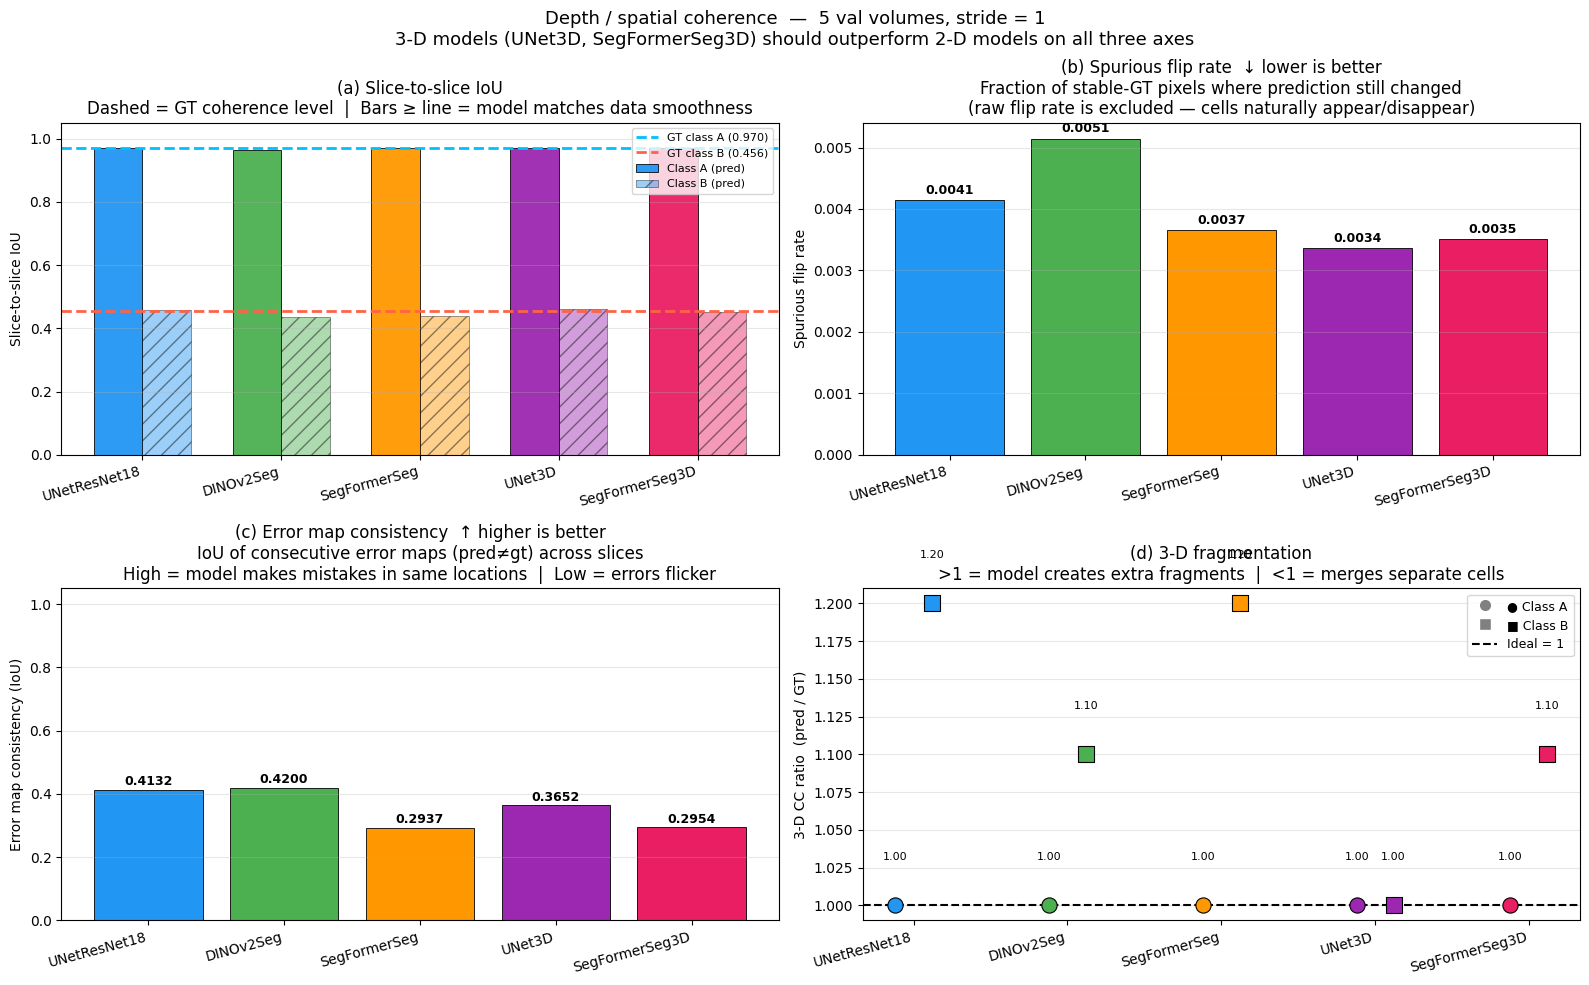


Model             SS-IoU A  GT ref A  SS-IoU B  GT ref B   Spur.flip   Err.cons.    CC-A    CC-B
---------------------------------------------------------------------------------------------------------
UNetResNet18        0.9686    0.9700    0.4576    0.4555     0.00414      0.4132   1.000   1.200
DINOv2Seg           0.9651    0.9700    0.4360    0.4560     0.00515      0.4200   1.000   1.100
SegFormerSeg        0.9705    0.9700    0.4405    0.4558     0.00366      0.2937   1.000   1.200
UNet3D              0.9695    0.9700    0.4612    0.4555     0.00336      0.3652   1.000   1.000
SegFormerSeg3D      0.9707    0.9700    0.4519    0.4558     0.00351      0.2954   1.000   1.100


In [19]:
# ── 17b. Coherence visualisation ─────────────────────────────────────────────
names   = list(COHERENCE)
colors  = [MODEL_SPECS[n]['color'] for n in names]
x       = np.arange(len(names))
bar_w   = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# ── (a) Slice-to-slice IoU vs GT reference ────────────────────────────────────
ax = axes[0]
ax.bar(x - bar_w/2, [COHERENCE[n]['ss_iou_A'] for n in names], bar_w,
       color=colors, alpha=0.95, edgecolor='k', linewidth=0.6, label='Class A (pred)')
ax.bar(x + bar_w/2, [COHERENCE[n]['ss_iou_B'] for n in names], bar_w,
       color=colors, alpha=0.45, edgecolor='k', linewidth=0.6, hatch='//', label='Class B (pred)')

# GT reference lines (same for all models — it's a data property)
gt_iou_A = np.mean([COHERENCE[n]['ss_iou_A_gt'] for n in names])
gt_iou_B = np.mean([COHERENCE[n]['ss_iou_B_gt'] for n in names])
ax.axhline(gt_iou_A, color='deepskyblue', lw=2, linestyle='--', label=f'GT class A ({gt_iou_A:.3f})')
ax.axhline(gt_iou_B, color='tomato',      lw=2, linestyle='--', label=f'GT class B ({gt_iou_B:.3f})')

ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Slice-to-slice IoU')
ax.set_title('(a) Slice-to-slice IoU\n'
             'Dashed = GT coherence level  |  Bars ≥ line = model matches data smoothness')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# ── (b) Spurious flip rate (lower = better) ───────────────────────────────────
ax = axes[1]
sf_vals = [COHERENCE[n]['spurious_flip'] for n in names]
bars = ax.bar(x, sf_vals, color=colors, edgecolor='k', linewidth=0.6)

for i, (n, v) in enumerate(zip(names, sf_vals)):
    ax.text(i, v + max(sf_vals) * 0.01, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Spurious flip rate')
ax.set_title('(b) Spurious flip rate  ↓ lower is better\n'
             'Fraction of stable-GT pixels where prediction still changed\n'
             '(raw flip rate is excluded — cells naturally appear/disappear)')
ax.grid(axis='y', alpha=0.3)

# ── (c) Error map consistency (higher = better) ───────────────────────────────
ax = axes[2]
ec_vals = [COHERENCE[n]['err_consistency'] for n in names]
bars = ax.bar(x, ec_vals, color=colors, edgecolor='k', linewidth=0.6)

for i, (n, v) in enumerate(zip(names, ec_vals)):
    ax.text(i, v + max(ec_vals) * 0.01, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('Error map consistency (IoU)')
ax.set_title('(c) Error map consistency  ↑ higher is better\n'
             'IoU of consecutive error maps (pred≠gt) across slices\n'
             'High = model makes mistakes in same locations  |  Low = errors flicker')
ax.grid(axis='y', alpha=0.3)

# ── (d) 3-D connected-components ratio ───────────────────────────────────────
ax = axes[3]
ax.axhline(1.0, color='k', lw=1.5, linestyle='--', label='Ideal (= GT)')

for i, (n, col) in enumerate(zip(names, colors)):
    ax.scatter(i - 0.12, COHERENCE[n]['cc_ratio_A'], s=120, color=col,
               marker='o', zorder=5, edgecolors='k', linewidths=0.8)
    ax.scatter(i + 0.12, COHERENCE[n]['cc_ratio_B'], s=120, color=col,
               marker='s', zorder=5, edgecolors='k', linewidths=0.8)
    ax.text(i - 0.12, COHERENCE[n]['cc_ratio_A'] + 0.03,
            f"{COHERENCE[n]['cc_ratio_A']:.2f}", ha='center', fontsize=8)
    if not np.isnan(COHERENCE[n]['cc_ratio_B']):
        ax.text(i + 0.12, COHERENCE[n]['cc_ratio_B'] + 0.03,
                f"{COHERENCE[n]['cc_ratio_B']:.2f}", ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('3-D CC ratio  (pred / GT)')
ax.set_title('(d) 3-D fragmentation\n'
             '>1 = model creates extra fragments  |  <1 = merges separate cells')
dot_A = plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', ms=9, label='● Class A')
dot_B = plt.Line2D([0],[0], marker='s', color='w', markerfacecolor='grey', ms=9, label='■ Class B')
ideal = plt.Line2D([0],[0], color='k', lw=1.5, linestyle='--', label='Ideal = 1')
ax.legend(handles=[dot_A, dot_B, ideal], fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Depth / spatial coherence  —  {len(COH_VAL_K)} val volumes, stride = 1\n'
             '3-D models (UNet3D, SegFormerSeg3D) should outperform 2-D models on all three axes',
             fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"Model":<16}  {"SS-IoU A":>8}  {"GT ref A":>8}  '
      f'{"SS-IoU B":>8}  {"GT ref B":>8}  '
      f'{"Spur.flip":>10}  {"Err.cons.":>10}  '
      f'{"CC-A":>6}  {"CC-B":>6}')
print('-' * 105)
for n in names:
    c = COHERENCE[n]
    cc_b = f'{c["cc_ratio_B"]:.3f}' if not np.isnan(c['cc_ratio_B']) else '  nan'
    print(f'{n:<16}  {c["ss_iou_A"]:8.4f}  {c["ss_iou_A_gt"]:8.4f}  '
          f'{c["ss_iou_B"]:8.4f}  {c["ss_iou_B_gt"]:8.4f}  '
          f'{c["spurious_flip"]:10.5f}  {c["err_consistency"]:10.4f}  '
          f'{c["cc_ratio_A"]:6.3f}  {cc_b:>6}')


---
## 18 · Worst-case slice visualisation

For each model, scan the first `SCAN_VOL_K` validation volumes and find the **`N_WORST` slices
with the lowest foreground mIoU**. Each row shows:

| Column | Content |
|---|---|
| Raw image | Input image resized to the model's training resolution |
| Ground truth | 3-class GT mask (black = bg, blue = cyto, red = nuc) |
| Prediction | Model output at the same resolution |
| Error map | Raw image with **red overlay** where `pred ≠ GT` |

These failure cases are useful for diagnosing *where* models struggle (e.g. slice extremes, touching cells, dim nuclei).


In [20]:

# ── 18. Worst-case slice scan ─────────────────────────────────────────────────
# For each model: scan SCAN_VOL_K validation volumes (stride = STRIDE),
# compute per-slice foreground mIoU, keep the N_WORST lowest.

N_WORST    = 3           # worst slices shown per model
SCAN_VOL_K = VAL_K[:8]  # how many val volumes to scan (more = slower but better coverage)

def _slice_fg_miou(pred, gt, classes=(1, 2)):
    """Mean IoU over foreground classes for a single 2-D slice."""
    ious = []
    for c in classes:
        inter = int(((pred == c) & (gt == c)).sum())
        union = int(((pred == c) | (gt == c)).sum())
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)) if ious else np.nan


worst_slices = {}   # name → [(miou, k, s, img_native, gt_modelres, pred), ...]

for name, model in MODELS.items():
    spec  = MODEL_SPECS[name]
    mode  = spec['mode']
    sz    = spec['img_size']
    depth = spec.get('depth', DEPTH_3D)
    half  = depth // 2

    records = []   # (miou, k, s, img_native, gt_s, pred_s)

    with torch.no_grad():
        for k in tqdm(SCAN_VOL_K, desc=name, leave=False):
            img_vol  = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).astype(np.float32) / 255.0
            msk_vol  = load_tif_stack(os.path.join(DATA_DIR, f'mask_{k}.tif'))
            n_slices = img_vol.shape[0]

            for s in range(0, n_slices, SLICE_STRIDE):
                gt_nat = process_mask(msk_vol[s])
                gt_s   = resize_gt(gt_nat, sz) if sz is not None else gt_nat

                if mode == '2d':
                    pred_s = predict_slice(model, img_vol[s], DEVICE, img_size=sz)
                else:
                    ids    = [max(0, min(n_slices - 1, s + d - half)) for d in range(depth)]
                    patch  = np.stack([img_vol[i] for i in ids])
                    pred_s = predict_slice_3d(model, patch, DEVICE, img_size=sz)

                miou = _slice_fg_miou(pred_s, gt_s)
                if not np.isnan(miou):
                    records.append((miou, k, s, img_vol[s].copy(), gt_s, pred_s))

    records.sort(key=lambda x: x[0])   # ascending mIoU → worst first
    worst_slices[name] = records[:N_WORST]
    print(f'{name:16s}  worst mIoUs: {[f"{r[0]:.3f}" for r in worst_slices[name]]}')

print('\nScan complete.')


UNetResNet18      worst mIoUs: ['0.479', '0.481', '0.486']


DINOv2Seg         worst mIoUs: ['0.470', '0.474', '0.474']


SegFormerSeg      worst mIoUs: ['0.487', '0.487', '0.490']


UNet3D            worst mIoUs: ['0.491', '0.511', '0.716']


SegFormerSeg3D    worst mIoUs: ['0.483', '0.487', '0.490']

Scan complete.


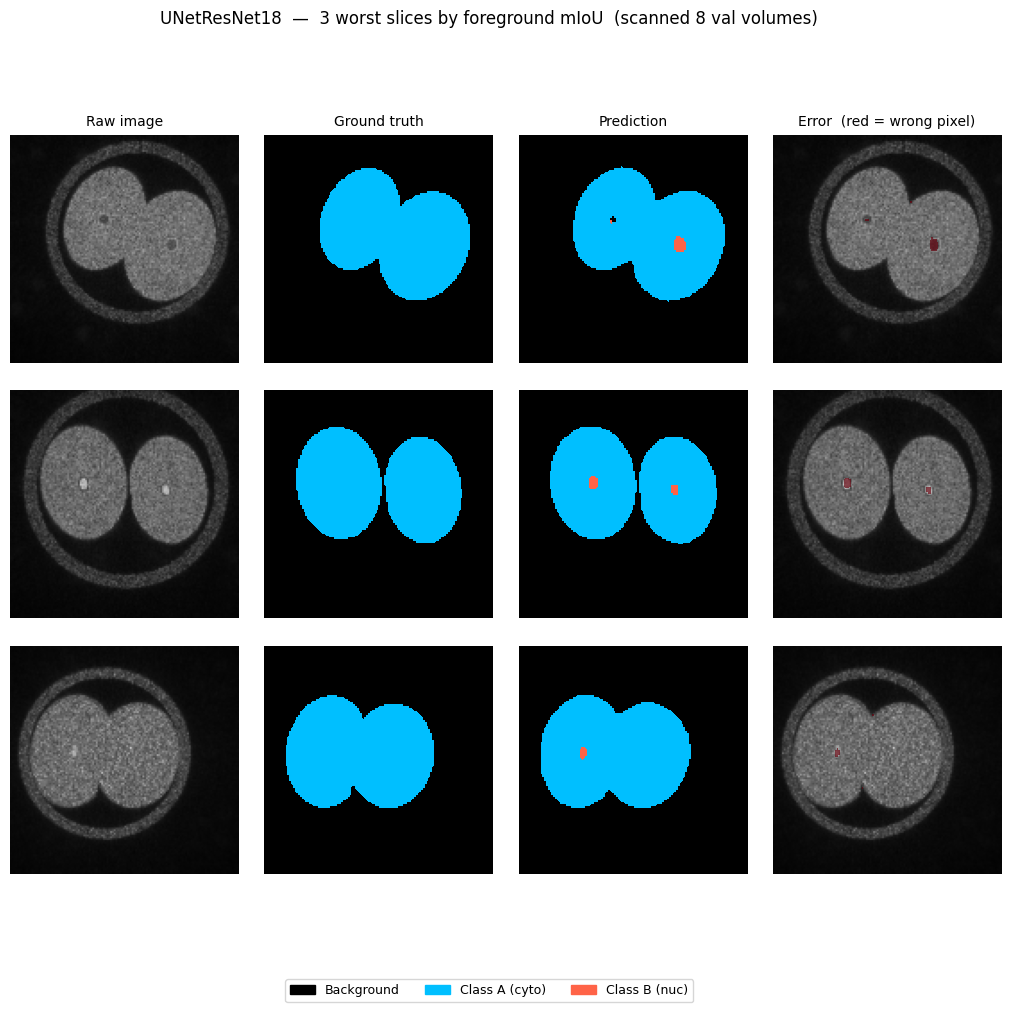

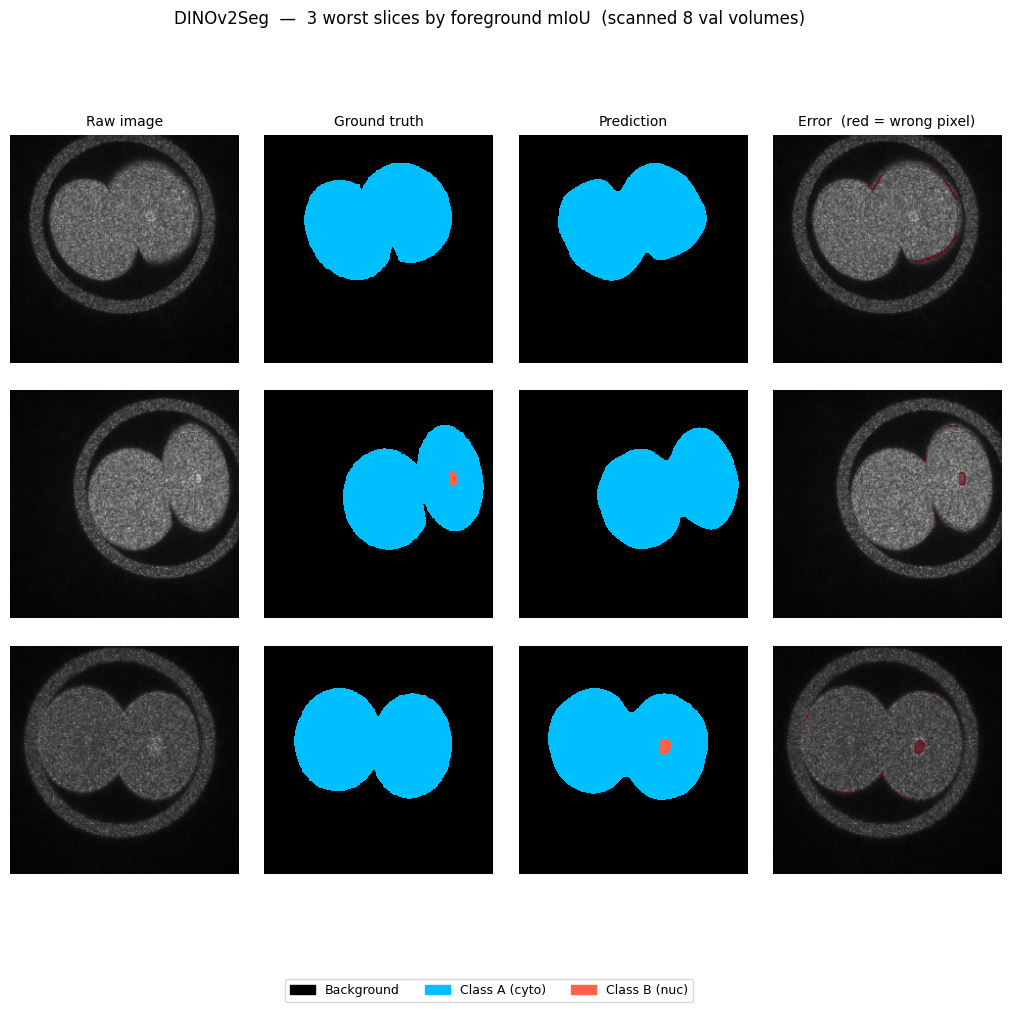

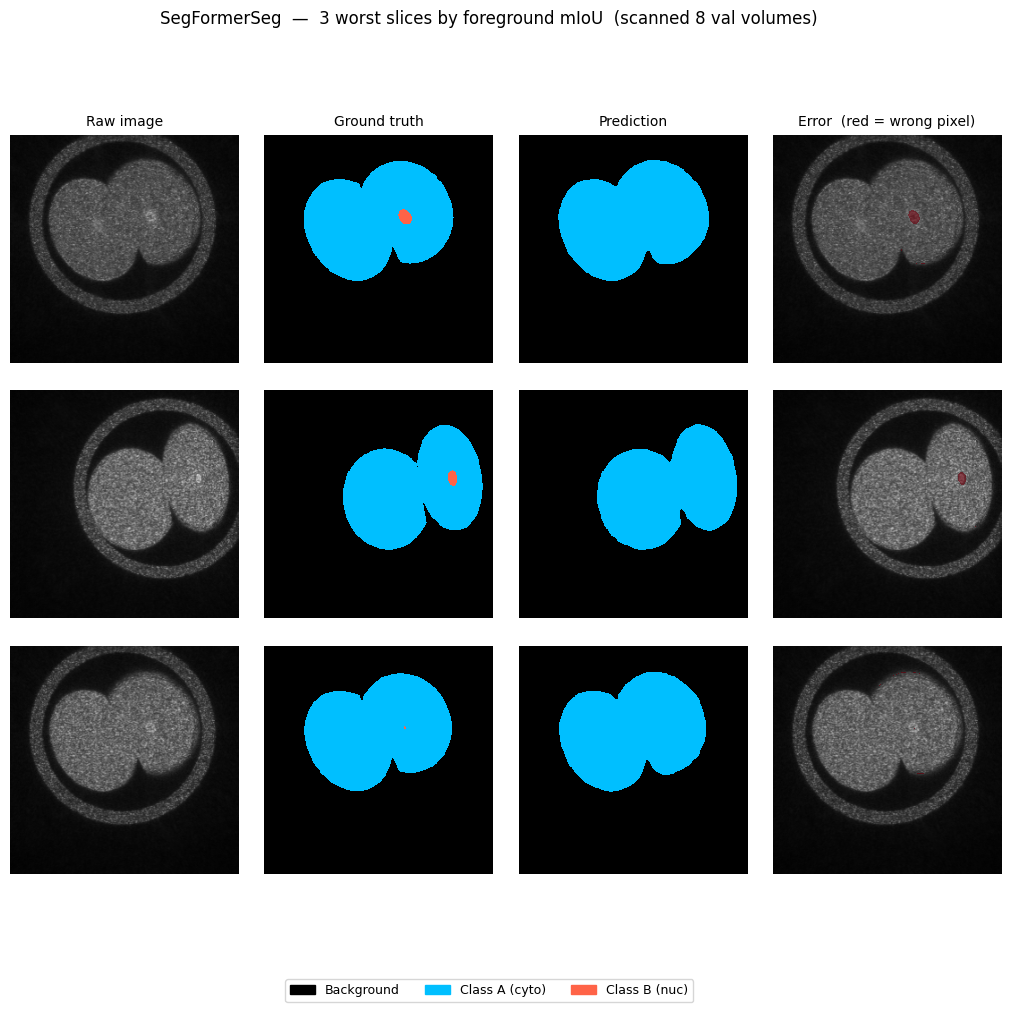

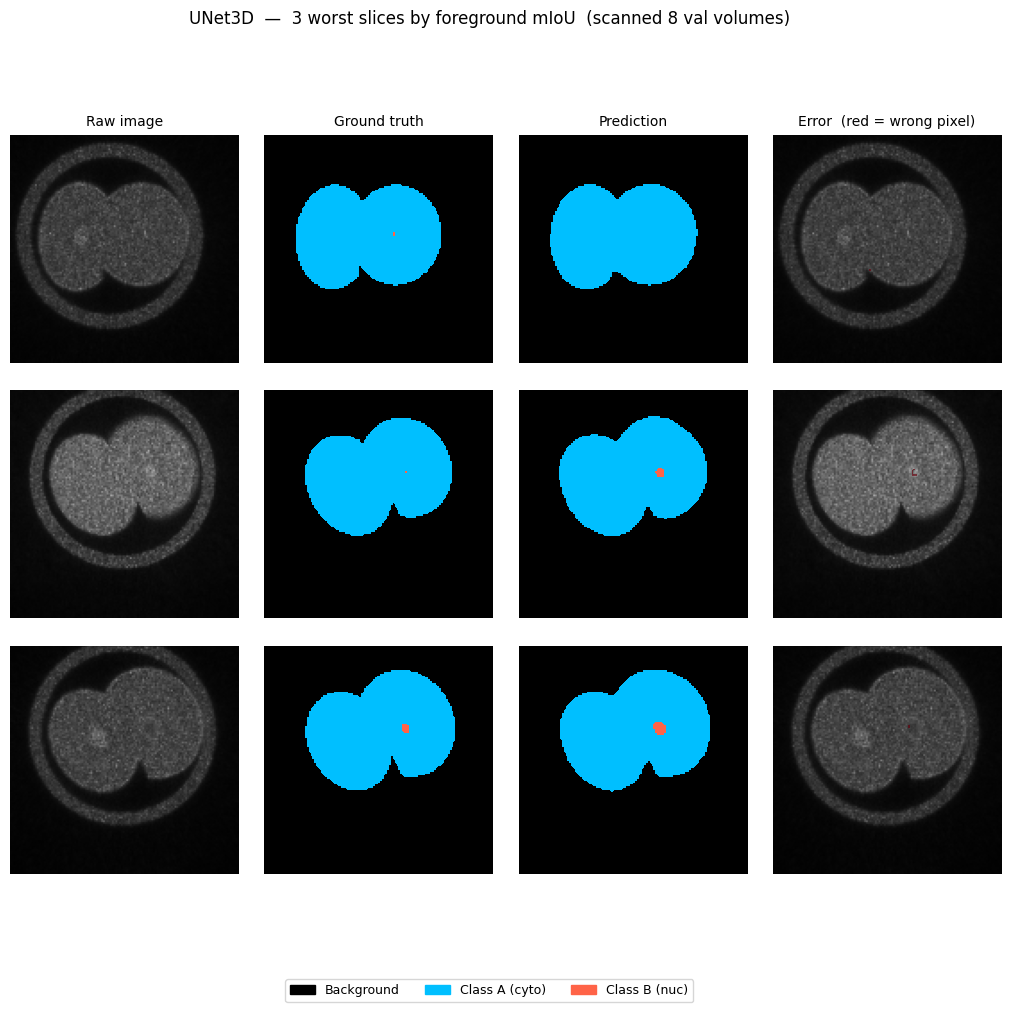

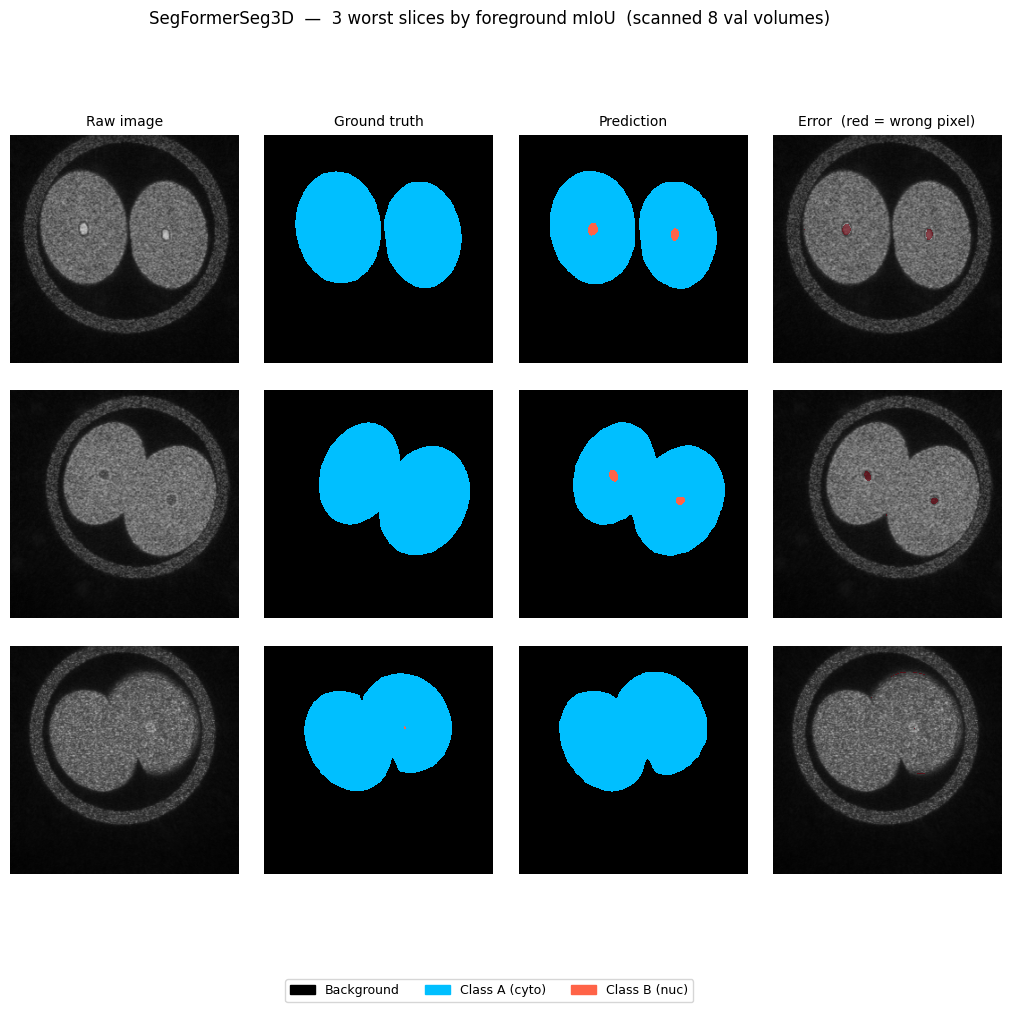

In [21]:

# ── 18b. Plot worst slices ────────────────────────────────────────────────────
# Columns per row: raw image | ground truth | prediction | error overlay

for name in MODELS:
    rows = worst_slices[name]
    n    = len(rows)
    if n == 0:
        continue

    fig, axes = plt.subplots(n, 4, figsize=(13, 3.2 * n),
                             gridspec_kw={'wspace': 0.04, 'hspace': 0.12})
    if n == 1:
        axes = axes[np.newaxis, :]

    sz = MODEL_SPECS[name]['img_size']

    col_titles = ['Raw image', 'Ground truth', 'Prediction', 'Error  (red = wrong pixel)']
    for ct, ax in zip(col_titles, axes[0]):
        ax.set_title(ct, fontsize=10)

    for row, (miou, k, s, img_nat, gt_s, pred_s) in enumerate(rows):
        # Resize raw image to model resolution for display
        if sz is not None:
            img_disp = F.interpolate(
                torch.from_numpy(img_nat).unsqueeze(0).unsqueeze(0).float(),
                size=sz, mode='bilinear', align_corners=False,
            ).squeeze().numpy()
        else:
            img_disp = img_nat

        err_mask = (pred_s != gt_s)

        axes[row, 0].imshow(img_disp, cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_ylabel(f'k={k}, s={s}\nmIoU={miou:.3f}', fontsize=8)

        axes[row, 1].imshow(gt_s,   cmap=CMAP, vmin=0, vmax=2)
        axes[row, 2].imshow(pred_s, cmap=CMAP, vmin=0, vmax=2)

        # Error map: grayscale image + red overlay where pred ≠ GT
        axes[row, 3].imshow(img_disp, cmap='gray', vmin=0, vmax=1)
        axes[row, 3].imshow(
            np.where(err_mask, 1.0, np.nan),
            cmap='Reds', vmin=0, vmax=1, alpha=0.65,
        )

        for ax in axes[row]:
            ax.axis('off')

    # Shared legend
    patches = [
        mpatches.Patch(color='black',      label='Background'),
        mpatches.Patch(color='deepskyblue', label='Class A (cyto)'),
        mpatches.Patch(color='tomato',      label='Class B (nuc)'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3,
               fontsize=9, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(
        f'{name}  —  {N_WORST} worst slices by foreground mIoU  '
        f'(scanned {len(SCAN_VOL_K)} val volumes)',
        fontsize=12, y=1.01,
    )
    plt.show()
